# Wavefield · Per-edge free surface — any subset of the four faces

``free_surface`` is not just a bool. Every propagator accepts a **per-edge
spec**: a list naming which faces of the domain are free surfaces, each free
face replacing its PML pad with the image-method boundary condition while the
remaining faces stay absorbing.

| ``free_surface=`` | Meaning |
|---|---|
| ``False`` *(default)* | absorbing on all four faces |
| ``True`` | historical top-only free surface |
| ``"top"`` / ``["top"]`` | same as ``True`` (single name or list) |
| ``["top", "left"]`` | free surface on two faces, absorbing elsewhere |
| ``{"bottom": True, "right": True}`` | dict form — face name → on/off |
| ``(True, False, True, False)`` / ``(1, 1, 1, 1)`` | canonical per-face bool/int tuple, axis-major ``(z_lo, z_hi, x_lo, x_hi)`` |
| ``["top", "bottom", "left", "right"]`` | **closed box** — no absorption at all (deepwave-style) |

Supported today: ``Acoustic`` and ``Elastic`` in 2-D, on both the eager and
the compiled CUDA backend, with gradients across every backward memory mode
(full / boundary-saving / checkpointing — see
``test_free_surface_per_edge_cuda.py``). 3-D supports the top face only, and
anisotropic equations (VTI/TTI) refuse a free surface entirely — the
isotropic image condition would be wrong physics there.

## 1. Parameters and uniform model

A uniform medium keeps the wavefronts clean so each boundary's behaviour is
unambiguous: whatever structure appears is put there by the edges, not the
model.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from sweep.equations import Elastic
from sweep.propagator.torch import PropTorch
from sweep.signal import ricker

shape = (200, 200)
dh    = 10.0
dt    = 0.0012
nt    = 900
freq, delay = 15.0, 0.07
vp_val, vs_val, rho_val = 2500.0, 1500.0, 2200.0

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

models = [torch.tensor(np.full(shape, v, dtype=np.float32), device=device)
          for v in (vp_val, vs_val, rho_val)]

src_iz, src_ix = shape[0] // 2, shape[1] // 2
sources = np.array([[src_ix, src_iz]], dtype=np.int64)

# coarse receiver grid over the whole interior -> a domain-energy proxy
g = np.arange(6, shape[1] - 6, 6, dtype=np.int64)
gx, gz = np.meshgrid(g, g, indexing='xy')
receivers = np.stack([gx.ravel(), gz.ravel()], -1)[None]

t = np.arange(nt, dtype=np.float32) * dt - delay
wavelet = torch.tensor(ricker(t, f=freq).astype(np.float32), device=device)
snapshot_times = [250, 500, 850]

device: cuda


## 2. Quick start — free surface on **all four faces**

This is the one line to remember: pass the list of faces. With all four
free the domain becomes a closed, perfectly reverberant box — nothing is
absorbed, everything reflects.

closed box: free faces = (True, True, True, True)  pad = (0, 0, 0, 0)


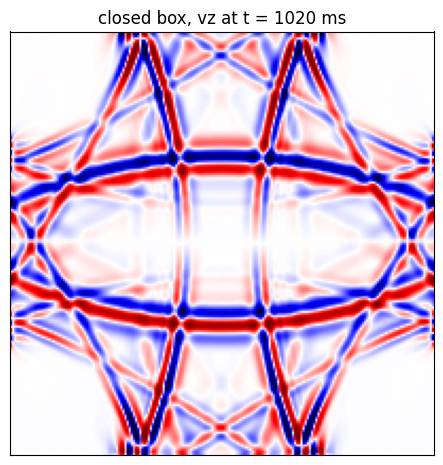

In [2]:
eq = Elastic(device=device)

solver = PropTorch(eq, shape=shape, dh=dh, dt=dt, nt=nt,
                   source_type=['sxx', 'szz'], receiver_type=['vz'],
                   free_surface=['top', 'bottom', 'left', 'right'],  # <-- all four faces
                   abcn=30, impl='eager', use_ckpt=False)

with torch.no_grad():
    rec_box, snaps_box = solver(wavelet, sources, receivers, models=models,
                                return_wavefield=True,
                                snapshot_times=snapshot_times)
print('closed box: free faces =', solver.fs_faces, ' pad =', solver.pad)

field = snaps_box[-1, 1, 0, 0].detach().cpu().numpy()
clip = np.percentile(np.abs(field), 99)
plt.figure(figsize=(5.5, 5.5))
plt.imshow(field, cmap='seismic', vmin=-clip, vmax=clip)
plt.title(f'closed box, vz at t = {snapshot_times[-1] * dt * 1e3:.0f} ms')
plt.xticks([]); plt.yticks([])
plt.show()

## 3. Every subset works — one solver per edge configuration

The only thing that changes between the four runs below is the
``free_surface=`` argument.

In [3]:
configs = [
    (False,                                'absorbing (no FS)'),
    (['top'],                              'top'),
    (['top', 'left'],                      'top + left'),
    (['top', 'bottom', 'left', 'right'],   'closed box (all4)'),
]

runs = []
for fs, label in configs:
    solver = PropTorch(eq, shape=shape, dh=dh, dt=dt, nt=nt,
                       source_type=['sxx', 'szz'], receiver_type=['vz'],
                       free_surface=fs, abcn=30,
                       impl='eager', use_ckpt=False)
    with torch.no_grad():
        rec, snaps = solver(wavelet, sources, receivers, models=models,
                            return_wavefield=True,
                            snapshot_times=snapshot_times)
    runs.append((label, snaps.detach().cpu().numpy(),
                 rec.detach().cpu().numpy(), solver.pad))
    print(f'{label:20s} snaps {tuple(snaps.shape)}  pad {solver.pad}')

absorbing (no FS)    snaps (3, 15, 1, 1, 260, 260)  pad (30, 30, 30, 30)


top                  snaps (3, 15, 1, 1, 230, 260)  pad (0, 30, 30, 30)


top + left           snaps (3, 15, 1, 1, 230, 230)  pad (0, 30, 0, 30)


closed box (all4)    snaps (3, 15, 1, 1, 200, 200)  pad (0, 0, 0, 0)


## 4. Snapshots

``vz`` at three times, one row per configuration (PML pads cropped — note a
free face has **no** pad, so the crop is per-edge too):

- **absorbing**: the P and S rings leave quietly through every face;
- **top**: the surface reflects the rings back down and hosts a Rayleigh
  wave along the free face;
- **top + left**: two mirrors — the corner produces the double-reflected
  images interfering with the direct rings;
- **closed box**: every face reflects; by the last frame the field is a
  fully reverberant superposition (nothing ever leaves).

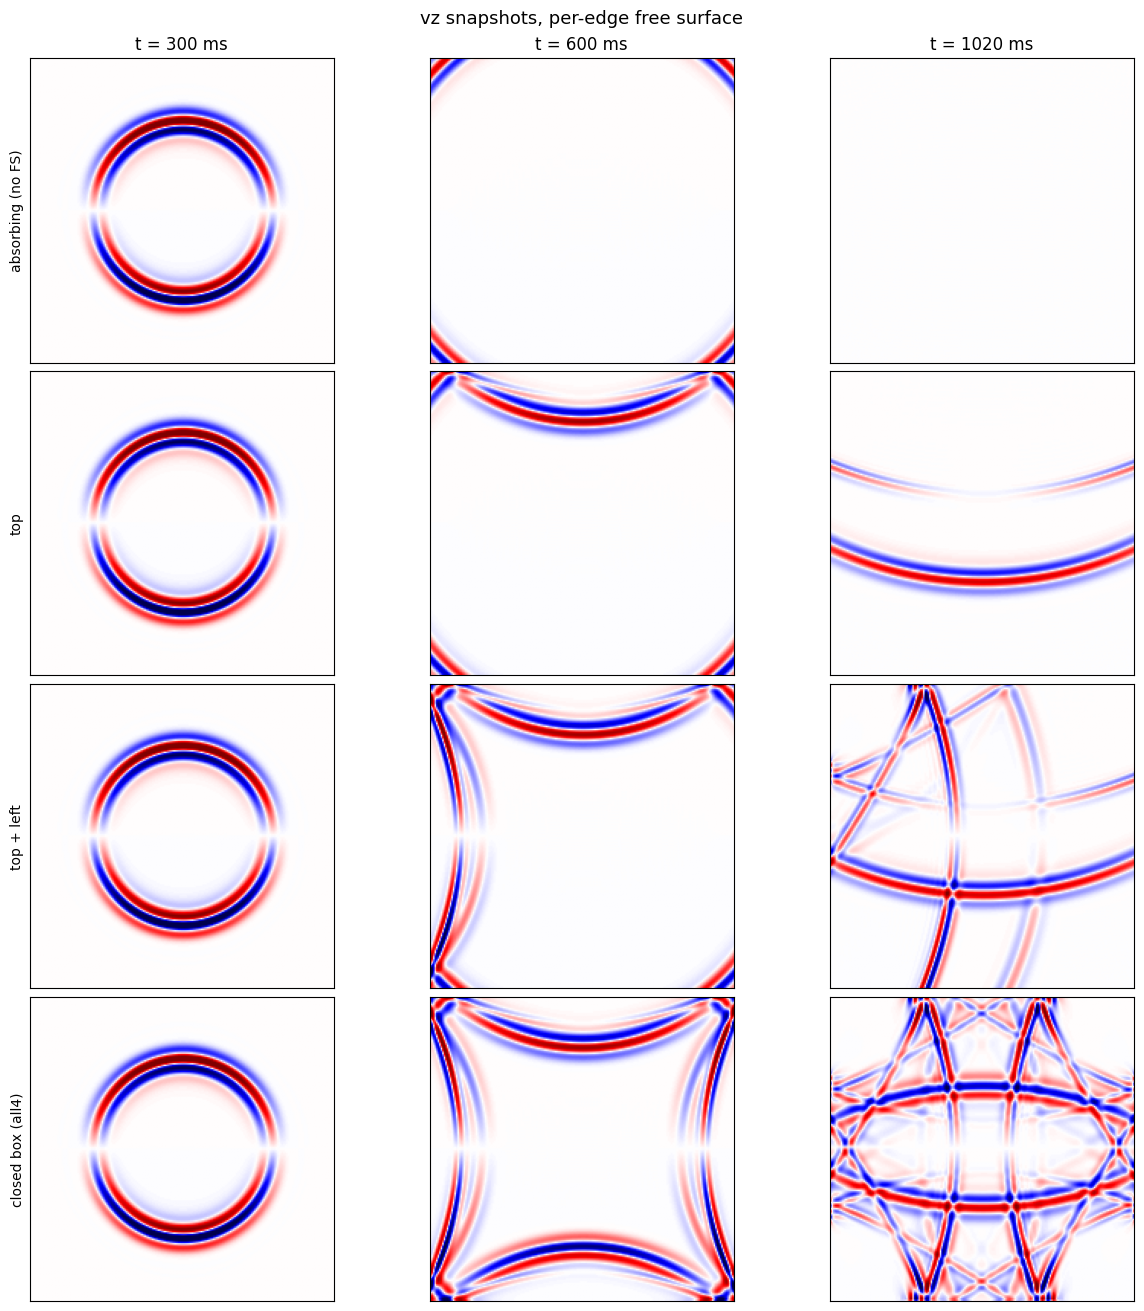

In [4]:
vz_index = 1
fig, axes = plt.subplots(len(runs), len(snapshot_times),
                         figsize=(12, 13), constrained_layout=True)
for row, (label, snaps, _, pad) in enumerate(runs):
    z_lo, z_hi, x_lo, x_hi = pad
    nz_pad, nx_pad = snaps.shape[-2:]
    # one clip per ROW (from the first frame): otherwise the absorbing
    # configuration's late frames normalize to numerical residue and look
    # like noise even though the field has simply left the domain.
    first = snaps[0, vz_index, 0, 0, z_lo:nz_pad - z_hi, x_lo:nx_pad - x_hi]
    clip = np.percentile(np.abs(first), 99)
    for col, t_idx in enumerate(snapshot_times):
        field = snaps[col, vz_index, 0, 0,
                      z_lo:nz_pad - z_hi, x_lo:nx_pad - x_hi]
        ax = axes[row, col]
        ax.imshow(field, cmap='seismic', vmin=-clip, vmax=clip, aspect='equal')
        if row == 0:
            ax.set_title(f't = {t_idx * dt * 1e3:.0f} ms')
        if col == 0:
            ax.set_ylabel(label, fontsize=10)
        ax.set_xticks([]); ax.set_yticks([])
fig.suptitle('vz snapshots, per-edge free surface', fontsize=13)
plt.show()

## 5. Energy: absorbing faces drain it, the closed box keeps it

Mean squared ``vz`` over the receiver grid. Each free face removes one
escape route; with all four free the energy has nowhere to go and the curve
plateaus — that plateau (rather than growth) is also a strict long-time
stability check on the boundary condition itself.

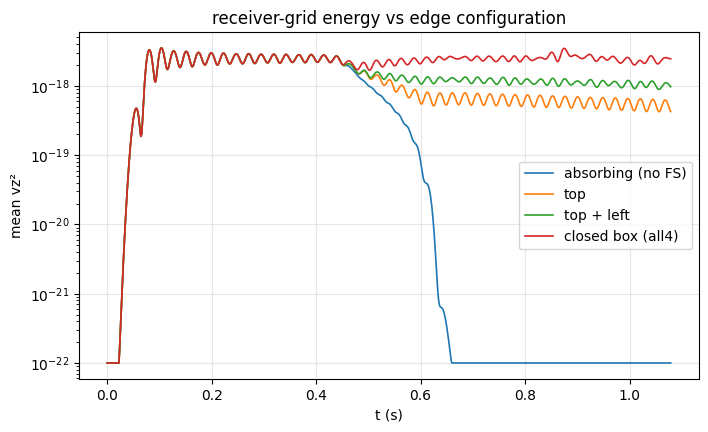

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))
tt = np.arange(nt) * dt
for label, _, rec, _ in runs:
    E = (rec[0, :, :, 0] ** 2).mean(axis=1)
    ax.semilogy(tt, np.maximum(E, 1e-22), lw=1.2, label=label)
ax.set_xlabel('t (s)'); ax.set_ylabel('mean vz²')
ax.legend(); ax.grid(alpha=0.3)
ax.set_title('receiver-grid energy vs edge configuration')
plt.show()

## 6. Gradients work on every configuration

The adjoint honours the same per-edge condition (CUDA + eager, all backward
memory modes — pinned by ``test_free_surface_per_edge_cuda.py``, which checks
every face and corner against the eager autograd reference at ``cos = 1.000``).
A quick sanity check on the hardest configuration:

In [6]:
m = [t.clone().requires_grad_(True) for t in models]
solver = PropTorch(eq, shape=shape, dh=dh, dt=dt, nt=nt,
                   source_type=['sxx', 'szz'], receiver_type=['vz'],
                   free_surface=['top', 'bottom', 'left', 'right'], abcn=30,
                   impl='eager', use_ckpt=False)
rec = solver(wavelet, sources, receivers, models=m)
rec.pow(2).sum().backward()
for name, g in zip(('vp', 'vs', 'rho'), (t.grad for t in m)):
    print(f'grad {name}: finite={bool(torch.isfinite(g).all())}, '
          f'|g|max={g.abs().max().item():.3e}')

grad vp: finite=True, |g|max=3.609e-15
grad vs: finite=True, |g|max=2.171e-15
grad rho: finite=True, |g|max=1.258e-15


## Notes and limits

- **3-D**: top-only (``free_surface=True``); a per-edge list raises.
- **Topography** (irregular surface) is a separate, top-only feature and
  cannot be combined with per-edge faces.
- **Anisotropic equations** (``AcousticVTI1st``, ``AcousticVTI``,
  ``AcousticTTI``, ``ElasticTTI(SG)``, …) raise ``NotImplementedError`` for
  any free surface: the anisotropic stress-free condition couples through
  the stiffness tensor and is not the isotropic image method.
- Per-edge PML thickness is also supported: pass a tuple to ``abcn=`` — see
  the [propagator user guide](../../user-guide/propagators/).